The source of the dataset is https://www.kaggle.com/datasets/gauthamp10/google-playstore-apps

## Dataset Metadata

### Source Information
- **Dataset**: Google Play Store Apps
- **Source**: [Kaggle - Google Play Store Apps](https://www.kaggle.com/datasets/gauthamp10/google-playstore-apps) by Gautham Prakash
- **File**: `Google-Playstore.csv`
- **Size**: 676.46 MB
- **Rows**: 2.3 Million+ applications
- **Columns**: 24 features
- **Scraped Date**: June 2021
- **Update Frequency**: Annually

---

### Column Descriptions

| Column | Data Type | Description | Notes |
|--------|-----------|-------------|-------|
| **App Name** | String | Name of the application | Unique per app, used as identifier |
| **App Id** | String | Unique identifier for the app | Format: `com.developer.appname` |
| **Category** | Categorical | App category/genre | 30+ categories including Game, Education, Tools, etc. |
| **Rating** | Float (0-5) | Average user rating | Stars, 0 = insufficient ratings |
| **Rating Count** | Integer | Number of user ratings | Proxy for review volume/engagement |
| **Installs** | Integer | Total install count | Binned values (e.g., "10+", "1,000+", "10,000,000+") |
| **Minimum Installs** | Integer | Lower bound of install range | Raw numeric value before binning |
| **Maximum Installs** | Integer | Upper bound of install range | Raw numeric value before binning |
| **Free** | Boolean | Free or paid app | True = free, False = paid |
| **Price** | Float (USD) | Price in USD | 0 for free apps |
| **Currency** | String | Currency code | USD, EUR, etc. (mostly USD) |
| **Size** | String | App size in MB/KB/GB | Values like "10M", "5.2M", "Varies with device" |
| **Minimum Android** | String | Minimum Android version required | Format: "X.X and up" |
| **Developer Id** | String | Developer's unique identifier | Typically email or company name format |
| **Developer Website** | String | Developer's official website URL | Nullable |
| **Developer Email** | String | Developer's contact email | Nullable |
| **Released** | Date | Initial release date | Format: "Month DD, YYYY" |
| **Last Updated** | Date | Last app update date | Format: "Month DD, YYYY" |
| **Content Rating** | Categorical | Age appropriateness rating | Everyone, Teen, Mature 17+, Everyone 10+, Adults only |
| **Privacy Policy** | String | Privacy policy URL | Nullable, indicates data handling transparency |
| **Ad Supported** | Boolean | Whether app displays ads | True/False |
| **In App Purchases** | Boolean | Whether app offers IAPs | True/False |
| **Editors Choice** | Boolean | Featured by Google Play editors | True/False |
| **Scraped Time** | DateTime | Timestamp of data collection | When the data was scraped |


In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Paths
RESULTS_DIR = '../results'
os.makedirs(RESULTS_DIR, exist_ok=True)

print(f'Results will be saved to: {os.path.abspath(RESULTS_DIR)}')

Results will be saved to: c:\Users\DELL\Documents\app-autopsy\results


# 1. Loading the Dataset

In [2]:
RAW_PATH = '../data/raw/Google-Playstore.csv'

df_raw = pd.read_csv(RAW_PATH, low_memory=False)

pd.set_option('display.max_columns', None)

print(f'Rows: {len(df_raw):,}  |  Columns: {df_raw.shape[1]}')
df_raw.head()

Rows: 2,312,944  |  Columns: 24


,App Name,App Id,Category,Rating,Rating Count,Installs,Minimum Installs,Maximum Installs,Free,Price,Currency,Size,Minimum Android,Developer Id,Developer Website,Developer Email,Released,Last Updated,Content Rating,Privacy Policy,Ad Supported,In App Purchases,Editors Choice,Scraped Time
0,Gakondo,com.ishakwe.gakondo,Adventure,0.0,0.0,10+,10.0,15,True,0.0,USD,10M,7.1 and up,Jean Confident Irénée NIYIZIBYOSE,https://beniyizibyose.tk/#/,jean21101999@gmail.com,"Feb 26, 2020","Feb 26, 2020",Everyone,https://beniyizibyose.tk/projects/,False,False,False,2021-06-15 20:19:35
1,Ampere Battery Info,com.webserveis.batteryinfo,Tools,4.4,64.0,"5,000+",5000.0,7662,True,0.0,USD,2.9M,5.0 and up,Webserveis,https://webserveis.netlify.app/,webserveis@gmail.com,"May 21, 2020","May 06, 2021",Everyone,https://dev4phones.wordpress.com/licencia-de-uso/,True,False,False,2021-06-15 20:19:35
2,Vibook,com.doantiepvien.crm,Productivity,0.0,0.0,50+,50.0,58,True,0.0,USD,3.7M,4.0.3 and up,Cabin Crew,NaN,vnacrewit@gmail.com,"Aug 9, 2019","Aug 19, 2019",Everyone,https://www.vietnamairlines.com/vn/en/terms-an...,False,False,False,2021-06-15 20:19:35
3,Smart City Trichy Public Service Vehicles 17UC...,cst.stJoseph.ug17ucs548,Communication,5.0,5.0,10+,10.0,19,True,0.0,USD,1.8M,4.0.3 and up,Climate Smart Tech2,http://www.climatesmarttech.com/,climatesmarttech2@gmail.com,"Sep 10, 2018","Oct 13, 2018",Everyone,NaN,True,False,False,2021-06-15 20:19:35
4,GROW.me,com.horodyski.grower,Tools,0.0,0.0,100+,100.0,478,True,0.0,USD,6.2M,4.1 and up,Rafal Milek-Horodyski,http://www.horodyski.com.pl,rmilekhorodyski@gmail.com,"Feb 21, 2020","Nov 12, 2018",Everyone,http://www.horodyski.com.pl,False,False,False,2021-06-15 20:19:35


# 2. Making a copy of the Dataframe

In [3]:
df = df_raw.copy()
print('Data copied to working DataFrame')

Data copied to working DataFrame


# 3. Normalizing Column Names

In [4]:
# Normalizing column names to snake_case for easier access
df.columns = (
    df.columns
      .str.strip()
      .str.lower()
      .str.replace(' ', '_')
      .str.replace(r'[^\w]', '_', regex=True)
)

print(df.columns.tolist())

['app_name', 'app_id', 'category', 'rating', 'rating_count', 'installs', 'minimum_installs', 'maximum_installs', 'free', 'price', 'currency', 'size', 'minimum_android', 'developer_id', 'developer_website', 'developer_email', 'released', 'last_updated', 'content_rating', 'privacy_policy', 'ad_supported', 'in_app_purchases', 'editors_choice', 'scraped_time']


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2312944 entries, 0 to 2312943
Data columns (total 24 columns):
 #   Column             Dtype  
---  ------             -----  
 0   app_name           str    
 1   app_id             str    
 2   category           str    
 3   rating             float64
 4   rating_count       float64
 5   installs           str    
 6   minimum_installs   float64
 7   maximum_installs   int64  
 8   free               bool   
 9   price              float64
 10  currency           str    
 11  size               str    
 12  minimum_android    str    
 13  developer_id       str    
 14  developer_website  str    
 15  developer_email    str    
 16  released           str    
 17  last_updated       str    
 18  content_rating     str    
 19  privacy_policy     str    
 20  ad_supported       bool   
 21  in_app_purchases   bool   
 22  editors_choice     bool   
 23  scraped_time       str    
dtypes: bool(4), float64(4), int64(1), str(15)
memory usage: 361.8

In [6]:
null_counts = df.isnull().sum()
null_pct = (null_counts / len(df) * 100).round(2)

null_df = pd.DataFrame({
    'null_count': null_counts,
    'null_pct': null_pct
}).sort_values('null_pct', ascending=False)

print(null_df[null_df['null_count'] > 0])

                   null_count  null_pct
developer_website      760835     32.89
privacy_policy         420953     18.20
released                71053      3.07
rating                  22883      0.99
rating_count            22883      0.99
minimum_android          6530      0.28
currency                  135      0.01
size                      196      0.01
minimum_installs          107      0.00
installs                  107      0.00
app_name                    5      0.00
developer_email            31      0.00
developer_id               33      0.00


# Visualizing missing data

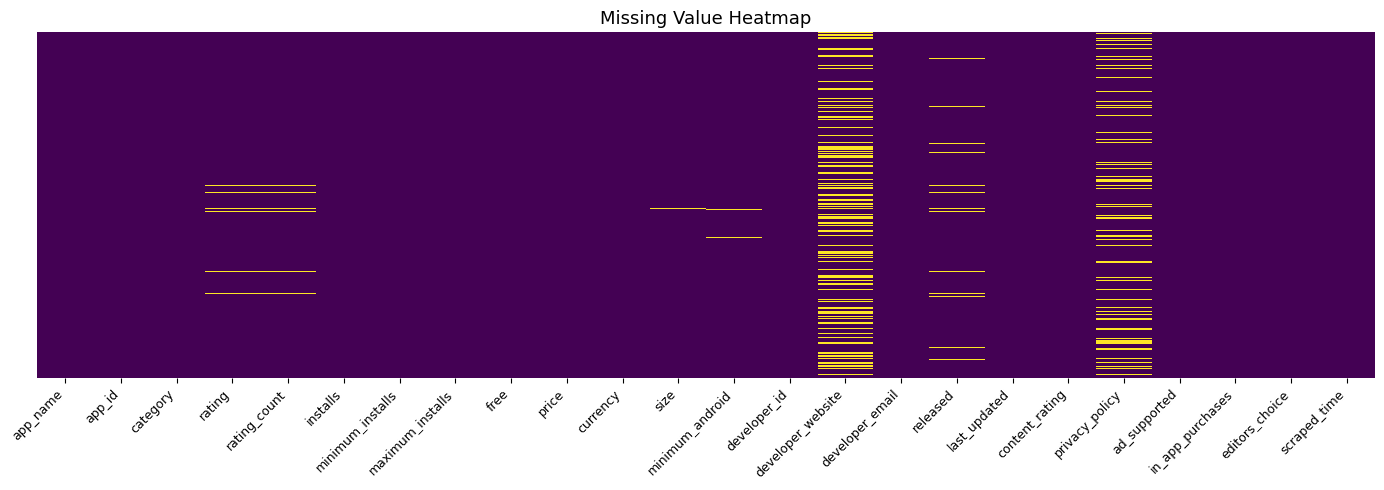

Saved to ../results/missing_values_heatmap.png


In [11]:
sample = df.isnull()

plt.figure(figsize=(14, 5))
sns.heatmap(
    sample,
    cbar=False,
    cmap='viridis',
    yticklabels=False
)
plt.title('Missing Value Heatmap', fontsize=13)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.tight_layout()

plt.savefig(f'{RESULTS_DIR}/missing_values_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved to {RESULTS_DIR}/missing_values_heatmap.png')

In [12]:
df['installs'] = pd.to_numeric(
    df['installs'].astype(str)
                  .str.replace(r'[+,]', '', regex=True)
                  .str.strip(),
    errors='coerce'
)

print(df['installs'].dtype)
print(df['installs'].describe())

float64
count    2.312837e+06
mean     1.834452e+05
std      1.513144e+07
min      0.000000e+00
25%      5.000000e+01
50%      5.000000e+02
75%      5.000000e+03
max      1.000000e+10
Name: installs, dtype: float64


#### Key Observations:
- The mean (183K) is much larger than the median (500) — a classic sign of a heavily right-skewed distribution. A few famous apps like Google Maps, Instagram, YouTube, etc. are pulling the average up massively.

- 25% is just 50 installs, 50% is 500, and 75% is 5,000 — which means half of all apps on the Play Store have under 500 installs. The market is extremely top-heavy.

- The max is 1e10 (10 billion) — that's one app, which must be a Google product.

In [13]:
def parse_size(s):
    s = str(s).strip().upper().replace(',', '')
    if s.endswith('M'): return float(s[:-1])
    if s.endswith('K'): return float(s[:-1]) / 1024
    if s.endswith('G'): return float(s[:-1]) * 1024
    return np.nan

df['size_mb'] = df['size'].apply(parse_size)

print(df['size_mb'].dtype)
print(df['size_mb'].describe())

float64
count    2.237971e+06
mean     1.920829e+01
std      2.404863e+01
min      3.125000e-03
25%      4.900000e+00
50%      1.000000e+01
75%      2.500000e+01
max      1.536000e+03
Name: size_mb, dtype: float64


#### Key Observations:
- median is 10MB — most apps are lightweight
- 75% is 25MB — only the top quarter of apps exceed 25MB
- max of 1536MB (1.5GB) — that must be a game
- min of 0.003MB (3KB) — suspiciously small, likely a miscoded entry, we'll ignore for now
- ~75K rows became NaN (2.31M → 2.24M) — these were 'Varies with device' entries

In [14]:
for col in ['released', 'last_updated', 'scraped_time']:
    df[col] = pd.to_datetime(df[col], errors='coerce', utc=True)

print(df[['released', 'last_updated', 'scraped_time']].dtypes)
print(df[['released', 'last_updated', 'scraped_time']].isnull().sum())

released        datetime64[us, UTC]
last_updated    datetime64[us, UTC]
scraped_time    datetime64[us, UTC]
dtype: object
released        71053
last_updated        0
scraped_time        0
dtype: int64


#### Key Observations:
- All three columns are now proper datetime
- released has 71,053 NaT values — 3% of apps have not listed their release date
- last_updated and scraped_time have no null values

### Fixing price and add monetization column

In [15]:
df['price'] = pd.to_numeric(df['price'], errors='coerce').fillna(0.0)

df['monetization'] = 'Free'
df.loc[df['price'] > 0, 'monetization'] = 'Paid'
df.loc[(df['price'] == 0) & (df['in_app_purchases'] == True), 'monetization'] = 'Freemium'

print(df['monetization'].value_counts())

monetization
Free        2075734
Freemium     192277
Paid          44933
Name: count, dtype: int64


### Creating derived feature: install_tier

In [16]:
install_bins   = [0, 1000, 10000, 100000, 1000000, 10000000, np.inf]
install_labels = ['<1K', '1K-10K', '10K-100K', '100K-1M', '1M-10M', '10M+']

df['install_tier'] = pd.cut(
    df['installs'],
    bins=install_bins,
    labels=install_labels,
    right=True
)

print(df['install_tier'].value_counts().sort_index())

install_tier
<1K         1640382
1K-10K       400316
10K-100K     185616
100K-1M       60662
1M-10M        12787
10M+           1508
Name: count, dtype: int64


In [17]:
print(f'Shape: {df.shape}')
print(f'Columns added: install_tier, size_mb, monetization')
print()
print(df[['installs', 'size_mb', 'price', 'monetization', 'install_tier', 
          'released', 'last_updated']].dtypes)

Shape: (2312944, 27)
Columns added: install_tier, size_mb, monetization

installs                    float64
size_mb                     float64
price                       float64
monetization                    str
install_tier               category
released        datetime64[us, UTC]
last_updated    datetime64[us, UTC]
dtype: object


In [19]:
CLEAN_PATH = '../data/processed/google_playstore_clean.csv'
os.makedirs('../data/processed', exist_ok=True)

df.to_csv(CLEAN_PATH, index=False)
print(f'Saved cleaned DataFrame to {CLEAN_PATH}')
print(f'Shape: {df.shape}')

Saved cleaned DataFrame to ../data/processed/google_playstore_clean.csv
Shape: (2312944, 27)
